## Part 1 - NBA Player Comparision

In [1]:
# As usual, we begin by importing the packages we will need

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# The data consists of the shot log for the NBA season 2016/17

shot = pd.read_csv("NBA shotlog_16_17.csv")
pd.set_option('display.max_columns', 100)
print(shot.columns.tolist())
shot.describe()

['self_previous_shot', 'player_position', 'home_game', 'location_x', 'opponent_previous_shot', 'home_team', 'shot_type', 'points', 'away_team', 'location_y', 'time', 'date', 'shoot_player', 'time_from_last_shot', 'quarter', 'current_shot_outcome']


,location_x,points,location_y,time_from_last_shot,quarter
count,209675.000000,210072.000000,209675.00000,200072.000000,210072.000000
mean,468.524507,2.316130,249.44723,33.279489,2.480383
std,345.063654,0.464965,111.02320,19.797357,1.136841
min,0.000000,2.000000,0.00000,0.000000,1.000000
25%,94.000000,2.000000,197.00000,22.000000,1.000000
50%,342.000000,2.000000,250.00000,31.000000,2.000000
75%,843.000000,3.000000,303.00000,41.000000,3.000000
max,933.000000,3.000000,500.00000,255.000000,8.000000


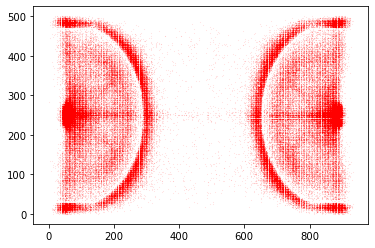

In [3]:
# A simple plot of coordinates

x = shot.location_x
y = shot.location_y
plt.scatter(x,y, s=.005, c='r', marker='.')

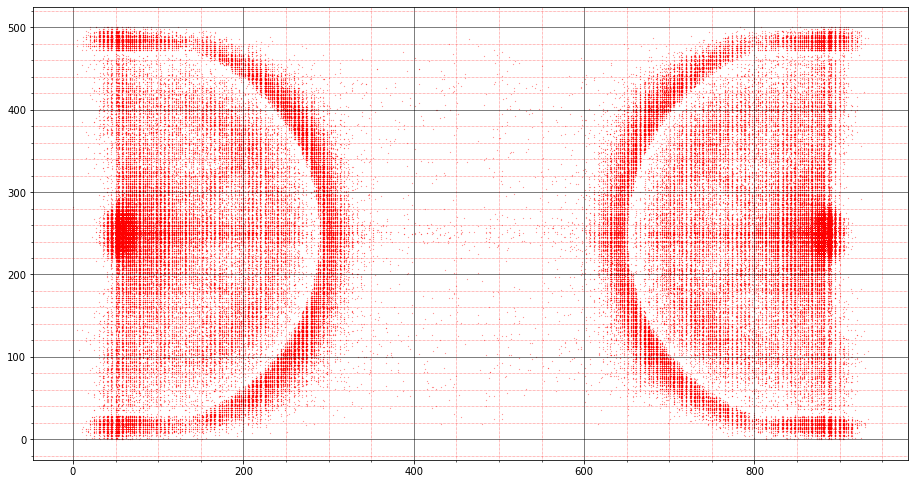

In [6]:
# A simple plot of coordinates 

plt.figure(figsize=(94/6, 50/6))
plt.scatter(x,y, s=.1, c='r', marker='.')
plt.minorticks_on()
plt.grid(which='major', linestyle='-',
         linewidth='.5', color = 'black')
plt.grid(which='minor', linestyle=':',
          linewidth='.5', color='red')

(466.5, 933.0)

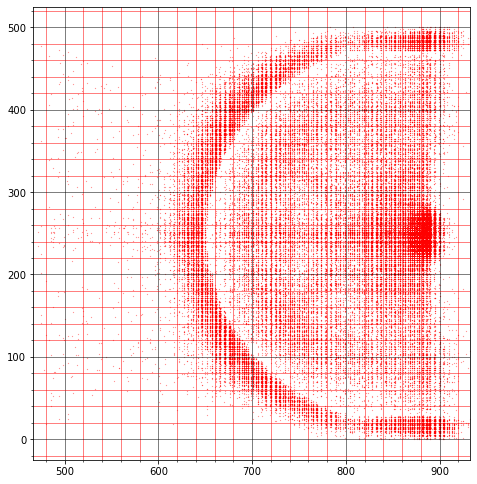

In [7]:
# The right hand half court
plt.figure(figsize=(94/12, 50/6))
plt.scatter(x,y, s=.1, c='r', marker='.')
plt.minorticks_on()
plt.grid(which='major', linewidth='.5', color='black')
plt.grid(which='minor', linewidth='.5', color='red')
plt.xlim(933/2, 933)

In [8]:
shot['halfcourt_x'] = np.where(shot.location_x < 933/2, 933 - shot.location_x, shot.location_x)
shot['halfcourt_y'] = np.where(shot.location_x < 933/2, 500 - shot.location_y, shot.location_y)
shot.describe()

,location_x,points,location_y,time_from_last_shot,quarter,halfcourt_x,halfcourt_y
count,209675.000000,210072.000000,209675.00000,200072.000000,210072.000000,209675.000000,209675.000000
mean,468.524507,2.316130,249.44723,33.279489,2.480383,799.731480,250.303947
std,345.063654,0.464965,111.02320,19.797357,1.136841,89.606222,111.024160
min,0.000000,2.000000,0.00000,0.000000,1.000000,468.000000,0.000000
25%,94.000000,2.000000,197.00000,22.000000,1.000000,720.000000,197.000000
50%,342.000000,2.000000,250.00000,31.000000,2.000000,841.000000,250.000000
75%,843.000000,3.000000,303.00000,41.000000,3.000000,878.000000,303.000000
max,933.000000,3.000000,500.00000,255.000000,8.000000,933.000000,500.000000


Text(0.5, 1.0, 'Shots')

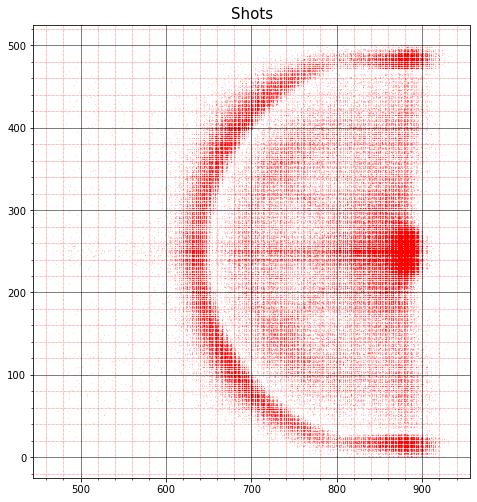

In [10]:
#all shots shown on a half court

hx = shot.halfcourt_x
hy = shot.halfcourt_y
plt.figure(figsize=(94/12, 50/6))
plt.scatter(hx,hy, s=.01, c='r', marker='.')
plt.minorticks_on()
plt.grid(which='major', linestyle='-', linewidth='.5', color='black')
plt.grid(which='minor', linestyle=':', linewidth='.5', color='red')
plt.title('Shots', fontsize=15)

In [12]:
#Comparing players

# We use a pivot table here to list players by shots
playersn = (shot.groupby('shoot_player')
                ['current_shot_outcome']
                .describe()
                .reset_index())
playersn.sort_values(by = 'count',
                     ascending = False)

,shoot_player,count,unique,top,freq
402,Russell Westbrook,1940,3,MISSED,1026
25,Andrew Wiggins,1568,3,MISSED,760
106,DeMar DeRozan,1545,3,MISSED,731
193,James Harden,1532,3,MISSED,772
28,Anthony Davis,1525,3,SCORED,770
...,...,...,...,...,...
111,Demetrius Jackson,4,2,SCORED,3
203,Jarrett Jack,3,2,SCORED,2
38,Ben Bentil,3,1,MISSED,3
202,Jarnell Stokes,1,1,SCORED,1


In [13]:
Durant = shot[shot.shoot_player == 'Kevin Durant']
Howard = shot[shot.shoot_player == 'Dwight Howard']
DeJordan = shot[shot.shoot_player == 'DeAndre Jordan']
Westbrook = shot[shot.shoot_player == 'Russell Westbrook']
BLopez = shot[shot.shoot_player == 'Brook Lopez']
RLopez = shot[shot.shoot_player == 'Robin Lopez']

## Westbrook - Durant Comparision

Text(0.5, 1.0, 'Russell Westbrook')

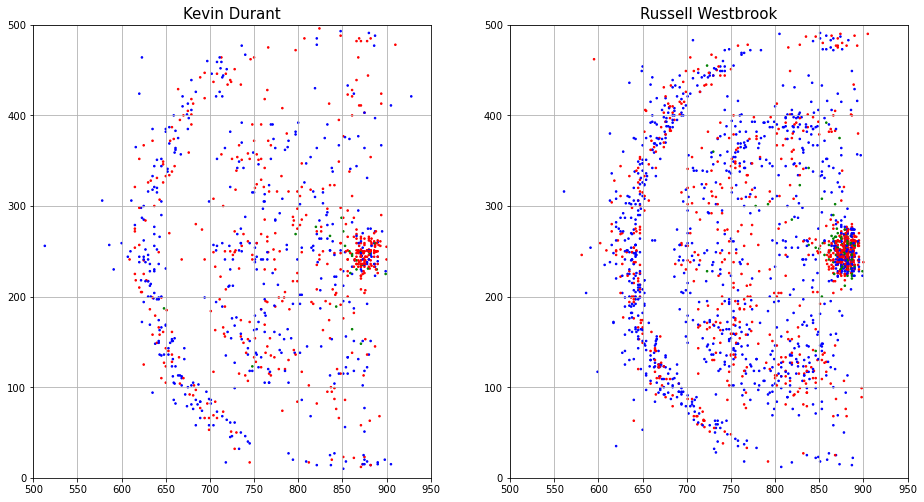

In [29]:
hx_KD = Durant.halfcourt_x
hy_KD = Durant.halfcourt_y

hx_RW = Westbrook.halfcourt_x
hy_RW = Westbrook.halfcourt_y

# Durant plot
f = plt.figure(figsize=(94/6, 50/6))
ax = f.add_subplot(121)

colors = np.where(Durant.current_shot_outcome == 'SCORED', 'r', \
            np.where(Durant.current_shot_outcome == 'MISSED', 'b', 'g'))
ax = plt.scatter(hx_KD, hy_KD, s = 10, c = colors, marker ='.')
plt.grid(True)
plt.xlim(500, 950)
plt.ylim(0,500)
plt.title('Kevin Durant', fontsize=15)

# Russell Westbrook plot
ax = f.add_subplot(122)
colors = np.where(Westbrook.current_shot_outcome == 'SCORED', 'r', \
            np.where(Westbrook.current_shot_outcome == 'MISSED', 'b', 'g'))
ax = plt.scatter(hx_RW, hy_RW, s = 10, c = colors, marker = '.')
plt.grid(True)
plt.xlim(500, 950)
plt.ylim(0,500)
plt.title('Russell Westbrook', fontsize=15)

## Jordan - Howard Comparision

Text(0.5, 1.0, 'DeAndre Jordan')

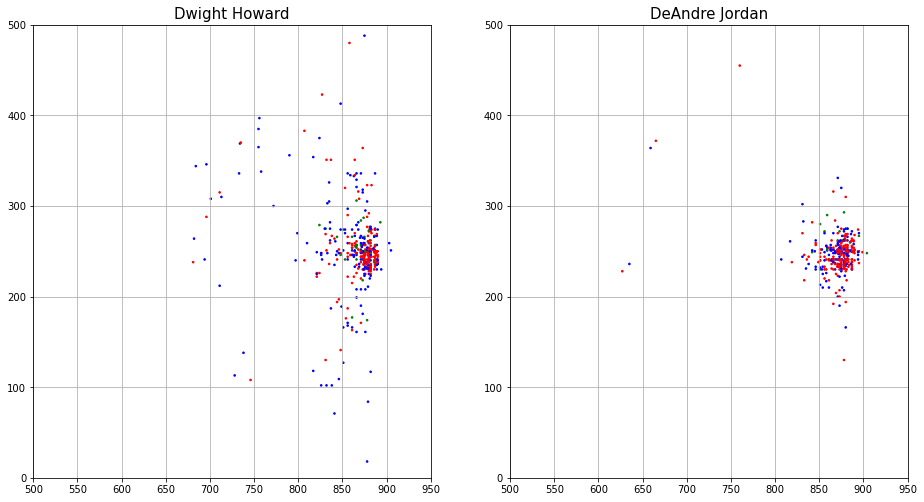

In [30]:
hx_DH = Howard.halfcourt_x
hy_DH = Howard.halfcourt_y

hx_DJ = DeJordan.halfcourt_x
hy_DJ = DeJordan.halfcourt_y

# Dwight Howard plot
f = plt.figure(figsize=(94/6, 50/6))
ax = f.add_subplot(121)
colors = np.where(Howard.current_shot_outcome == 'SCORED', 'r', \
            np.where(Howard.current_shot_outcome == 'MISSED', 'b', 'g'))

ax = plt.scatter(hx_DH, hy_DH, s = 10, c = colors, marker = '.')
plt.grid(True)
plt.xlim(500, 950)
plt.ylim(0,500)
plt.title('Dwight Howard', fontsize=15)

# DeAndre Jordan plot
ax = f.add_subplot(122)
colors = np.where(DeJordan.current_shot_outcome == 'SCORED', 'r', \
            np.where(DeJordan.current_shot_outcome == 'MISSED', 'b', 'g'))
ax = plt.scatter(hx_DJ, hy_DJ, s = 10, c = colors, marker = '.')
plt.grid(True)
plt.xlim(500, 950)
plt.ylim(0,500)
plt.title('DeAndre Jordan', fontsize=15)

## Lopez - Lopez Comparision

Text(0.5, 1.0, 'Robin Lopez')

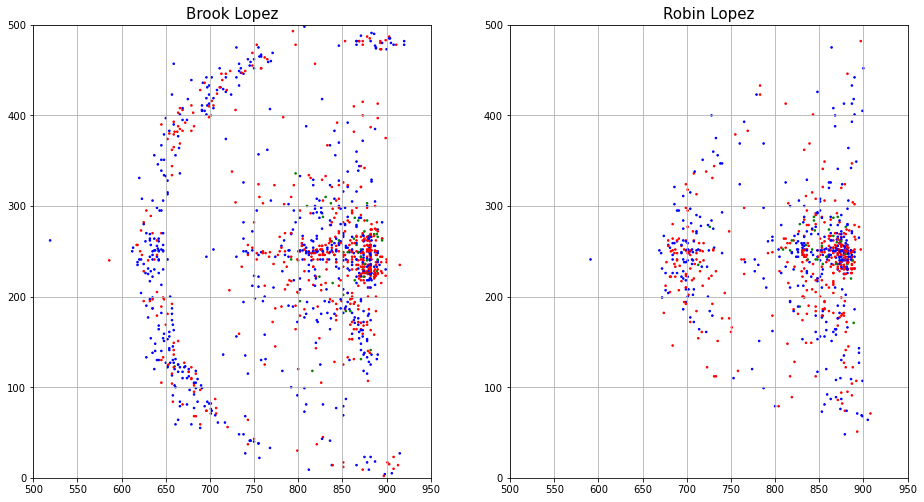

In [32]:
hx_BL = BLopez.halfcourt_x
hy_BL = BLopez.halfcourt_y

hx_RL = RLopez.halfcourt_x
hy_RL = RLopez.halfcourt_y

# Brook Lopez plot
f = plt.figure(figsize=(94/6, 50/6))
ax = f.add_subplot(121)
colors = np.where(BLopez.current_shot_outcome == 'SCORED', 'r', \
            np.where(BLopez.current_shot_outcome == 'MISSED', 'b', 'g'))

ax = plt.scatter(hx_BL, hy_BL, s = 10, c = colors, marker = '.')
plt.grid(True)
plt.xlim(500, 950)
plt.ylim(0,500)
plt.title('Brook Lopez', fontsize=15)

# Robin Jordan plot
ax = f.add_subplot(122)
colors = np.where(RLopez.current_shot_outcome == 'SCORED', 'r', \
            np.where(RLopez.current_shot_outcome == 'MISSED', 'b', 'g'))
ax = plt.scatter(hx_RL, hy_RL, s = 10, c = colors, marker = '.')
plt.grid(True)
plt.xlim(500, 950)
plt.ylim(0,500)
plt.title('Robin Lopez', fontsize=15)